In [317]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

data3 = pd.read_csv("Best Copy of Energy Data for CS ML 2000-2022 - Sheet1.csv")
future_data3 = pd.read_csv("Best Copy of Energy Data for CS ML 2000-2022 - Sheet1.csv")
data3.head()

,country,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,...,elec_gen_solar,elec_gen_wind,elec_gen_solar_thermal,elec_gen_geothermal,elec_gen_sol/geothermal,elec_gen_tide,elec_gen_other,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita
0,Australia,2000,2015828,806999,58896,0,3763,210841,1429894,175846,...,38,58,0,0,0,0,0,195.244,17.585955,45979.07657
1,Australia,2001,2018544,850415,59626,0,4531,212965,1281399,165416,...,44,210,0,0,0,0,0,206.484,17.690257,46314.62353
2,Australia,2002,2034808,788516,57157,0,5161,226713,1360752,125943,...,50,364,0,0,0,0,0,211.730,17.892464,47599.40793
3,Australia,2003,2015734,856586,58586,0,5521,219530,1480641,144840,...,58,703,1,0,1,0,0,207.548,17.665647,48509.66322
4,Australia,2004,2089200,859874,57996,0,5404,216460,1488010,151394,...,68,705,1,0,1,0,0,212.475,18.149135,50018.59045


In [318]:
data3["country"] = data3["country"].str.strip()
future_data3["country"] = future_data3["country"].str.strip()

In [319]:
data3["country_code"] = data3["country"].astype("category").cat.codes
future_data3["country_code"] = future_data3["country"].astype("category").cat.codes

In [320]:
data3["renew/sus_elec_gen"] = data3["elec_gen_solar"] + data3["elec_gen_wind"] + data3["elec_gen_hydro/tide"] + data3["elec_gen_sol/geothermal"]
future_data3["renew/sus_elec_gen"] = future_data3["elec_gen_solar"] + future_data3["elec_gen_wind"] + future_data3["elec_gen_hydro/tide"] + future_data3["elec_gen_sol/geothermal"]

In [321]:
data3["elec_gen_total"] = data3["renew/sus_elec_gen"] + data3["elec_gen_oil"] + data3["elec_gen_coal"] + data3["elec_gen_biofuels"] + data3["elec_gen_natural_gas"] + data3["elec_gen_nuclear"] + data3["elec_gen_other"] + data3["elec_gen_waste"]
future_data3["elec_gen_total"] = future_data3["renew/sus_elec_gen"] + future_data3["elec_gen_oil"] + future_data3["elec_gen_coal"] + future_data3["elec_gen_biofuels"] + future_data3["elec_gen_natural_gas"] + future_data3["elec_gen_nuclear"] + future_data3["elec_gen_other"] + future_data3["elec_gen_waste"]

In [322]:
data3["true_renew_share"] = data3["renew/sus_elec_gen"] / data3["elec_gen_total"]
future_data3["true_renew_share"] = future_data3["renew/sus_elec_gen"] / future_data3["elec_gen_total"]


In [323]:
# data3["renew_share_change"] = data3.groupby("country_code")["true_renew_share"].diff()
# future_data3["renew_share_change"] = future_data3.groupby("country_code")["true_renew_share"].diff()

In [324]:
future_data3

,country,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,...,elec_gen_sol/geothermal,elec_gen_tide,elec_gen_other,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita,country_code,renew/sus_elec_gen,elec_gen_total,true_renew_share
0,Australia,2000,2015828,806999,58896,0,3763,210841,1429894,175846,...,0,0,0,195.244,17.585955,45979.07657,0,16816,210224,0.079991
1,Australia,2001,2018544,850415,59626,0,4531,212965,1281399,165416,...,0,0,0,206.484,17.690257,46314.62353,0,17187,224635,0.076511
2,Australia,2002,2034808,788516,57157,0,5161,226713,1360752,125943,...,0,0,0,211.730,17.892464,47599.40793,0,16468,227555,0.072369
3,Australia,2003,2015734,856586,58586,0,5521,219530,1480641,144840,...,1,0,0,207.548,17.665647,48509.66322,0,17252,220802,0.078133
4,Australia,2004,2089200,859874,57996,0,5404,216460,1488010,151394,...,1,0,0,212.475,18.149135,50018.59045,0,17105,228434,0.074879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892,United States,2018,13426291,29054726,1063803,9178130,1841813,4393036,33566263,701165,...,22713,0,5272,4288.759,14.934503,59526.66570,38,696795,4455434,0.156392
893,United States,2019,11510279,31078534,1043274,9199964,1934725,4445624,33293509,644740,...,21897,0,5074,4186.693,14.355887,60750.98986,38,724610,4391756,0.164993
894,United States,2020,9280479,30104803,1033702,8979813,2180848,4108850,29400955,540438,...,22256,0,4865,4109.389,12.830346,59194.66652,38,788187,4260036,0.185019
895,United States,2021,10635146,30274618,912523,8853288,2455808,4383684,31968560,567856,...,22246,0,4687,4169.876,13.681768,62680.25036,38,827308,4374671,0.189113


In [325]:
data3

,country,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,...,elec_gen_sol/geothermal,elec_gen_tide,elec_gen_other,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita,country_code,renew/sus_elec_gen,elec_gen_total,true_renew_share
0,Australia,2000,2015828,806999,58896,0,3763,210841,1429894,175846,...,0,0,0,195.244,17.585955,45979.07657,0,16816,210224,0.079991
1,Australia,2001,2018544,850415,59626,0,4531,212965,1281399,165416,...,0,0,0,206.484,17.690257,46314.62353,0,17187,224635,0.076511
2,Australia,2002,2034808,788516,57157,0,5161,226713,1360752,125943,...,0,0,0,211.730,17.892464,47599.40793,0,16468,227555,0.072369
3,Australia,2003,2015734,856586,58586,0,5521,219530,1480641,144840,...,1,0,0,207.548,17.665647,48509.66322,0,17252,220802,0.078133
4,Australia,2004,2089200,859874,57996,0,5404,216460,1488010,151394,...,1,0,0,212.475,18.149135,50018.59045,0,17105,228434,0.074879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892,United States,2018,13426291,29054726,1063803,9178130,1841813,4393036,33566263,701165,...,22713,0,5272,4288.759,14.934503,59526.66570,38,696795,4455434,0.156392
893,United States,2019,11510279,31078534,1043274,9199964,1934725,4445624,33293509,644740,...,21897,0,5074,4186.693,14.355887,60750.98986,38,724610,4391756,0.164993
894,United States,2020,9280479,30104803,1033702,8979813,2180848,4108850,29400955,540438,...,22256,0,4865,4109.389,12.830346,59194.66652,38,788187,4260036,0.185019
895,United States,2021,10635146,30274618,912523,8853288,2455808,4383684,31968560,567856,...,22246,0,4687,4169.876,13.681768,62680.25036,38,827308,4374671,0.189113


In [326]:
data3["renew_share_next"] = data3.groupby("country_code")["true_renew_share"].shift(-1)

In [327]:
data3["renew_share_change"] = data3["renew_share_next"] - data3["true_renew_share"]


In [328]:
data3 = data3.dropna(subset=["renew_share_change"])
data3

,country,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,...,elec_gen_other,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita,country_code,renew/sus_elec_gen,elec_gen_total,true_renew_share,renew_share_next,renew_share_change
0,Australia,2000,2015828,806999,58896,0,3763,210841,1429894,175846,...,0,195.244,17.585955,45979.07657,0,16816,210224,0.079991,0.076511,-0.003480
1,Australia,2001,2018544,850415,59626,0,4531,212965,1281399,165416,...,0,206.484,17.690257,46314.62353,0,17187,224635,0.076511,0.072369,-0.004141
2,Australia,2002,2034808,788516,57157,0,5161,226713,1360752,125943,...,0,211.730,17.892464,47599.40793,0,16468,227555,0.072369,0.078133,0.005764
3,Australia,2003,2015734,856586,58586,0,5521,219530,1480641,144840,...,0,207.548,17.665647,48509.66322,0,17252,220802,0.078133,0.074879,-0.003254
4,Australia,2004,2089200,859874,57996,0,5404,216460,1488010,151394,...,0,212.475,18.149135,50018.59045,0,17105,228434,0.074879,0.072495,-0.002384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,United States,2017,13847655,26960229,1088504,9151214,1661988,4126342,33087374,712304,...,5443,4116.629,14.566783,58151.70214,38,672067,4286422,0.156790,0.156392,-0.000398
892,United States,2018,13426291,29054726,1063803,9178130,1841813,4393036,33566263,701165,...,5272,4288.759,14.934503,59526.66570,38,696795,4455434,0.156392,0.164993,0.008601
893,United States,2019,11510279,31078534,1043274,9199964,1934725,4445624,33293509,644740,...,5074,4186.693,14.355887,60750.98986,38,724610,4391756,0.164993,0.185019,0.020026
894,United States,2020,9280479,30104803,1033702,8979813,2180848,4108850,29400955,540438,...,4865,4109.389,12.830346,59194.66652,38,788187,4260036,0.185019,0.189113,0.004094


In [329]:
y3 = data3["renew_share_change"]
y3

0     -0.003480
1     -0.004141
2      0.005764
3     -0.003254
4     -0.002384
         ...   
891   -0.000398
892    0.008601
893    0.020026
894    0.004094
895    0.016554
Name: renew_share_change, Length: 858, dtype: float64

In [330]:
X3 = data3.drop(columns=["renew_share_change", "renew_share_next", "country", "co2_emissions_total", "elec_gen_hydro", "elec_gen_tide", "elec_gen_geothermal",
                              "elec_gen_solar_thermal", "elec_gen_sol/geothermal", "elec_gen_hydro/tide", "elec_gen_solar", "elec_gen_wind", "elec_gen_total", "renew/sus_elec_gen",
                              "co2_emissions_coal", "co2_emissions_oil", "co2_emissions_natural_gas", "co2_emissions_other", "co2_emissions_elec_gen_incl_chp", 
                              "elec_gen_coal", "elec_gen_oil", "elec_gen_natural_gas", "elec_gen_biofuels", "elec_gen_waste", "elec_gen_nuclear", "elec_gen_other", "true_renew_share", "country_code"])
X3

,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,tfc_oil,tfc_natural_gas,tfc_solar_wind,tfc_biofuels,tfc_electricity,tfc_heat,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita
0,2000,2015828,806999,58896,0,3763,210841,1429894,175846,1453500,476844,3417,181752,621896,0,195.244,17.585955,45979.07657
1,2001,2018544,850415,59626,0,4531,212965,1281399,165416,1438847,503116,3617,180038,649432,0,206.484,17.690257,46314.62353
2,2002,2034808,788516,57157,0,5161,226713,1360752,125943,1417203,494640,3670,190811,688021,0,211.730,17.892464,47599.40793
3,2003,2015734,856586,58586,0,5521,219530,1480641,144840,1479100,529306,2775,145331,665769,0,207.548,17.665647,48509.66322
4,2004,2089200,859874,57996,0,5404,216460,1488010,151394,1525625,539122,2616,137087,681541,0,212.475,18.149135,50018.59045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,2017,13847655,26960229,1088504,9151214,1661988,4126342,33087374,712304,31115924,14499416,88557,3237927,13522015,245406,4116.629,14.566783,58151.70214
892,2018,13426291,29054726,1063803,9178130,1841813,4393036,33566263,701165,31739161,15934768,148035,3503246,14043151,260320,4288.759,14.934503,59526.66570
893,2019,11510279,31078534,1043274,9199964,1934725,4445624,33293509,644740,31622507,16018751,127018,3590849,13787827,252619,4186.693,14.355887,60750.98986
894,2020,9280479,30104803,1033702,8979813,2180848,4108850,29400955,540438,27963136,14924938,128891,3294752,13600044,249865,4109.389,12.830346,59194.66652


In [331]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

X3_columns = X3.columns

train = data3[data3["year"] <= 2018]
test = data3[data3["year"] > 2018]

X3_train = train[X3_columns]
y3_train = train["renew_share_change"]

X3_test = test[X3_columns]
y3_test = test["renew_share_change"]

RF_model3 = RandomForestRegressor(n_estimators=200, random_state=42)
RF_model3.fit(X3_train, y3_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [332]:
X3_train

,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,tfc_oil,tfc_natural_gas,tfc_solar_wind,tfc_biofuels,tfc_electricity,tfc_heat,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita
0,2000,2015828,806999,58896,0,3763,210841,1429894,175846,1453500,476844,3417,181752,621896,0,195.244,17.585955,45979.07657
1,2001,2018544,850415,59626,0,4531,212965,1281399,165416,1438847,503116,3617,180038,649432,0,206.484,17.690257,46314.62353
2,2002,2034808,788516,57157,0,5161,226713,1360752,125943,1417203,494640,3670,190811,688021,0,211.730,17.892464,47599.40793
3,2003,2015734,856586,58586,0,5521,219530,1480641,144840,1479100,529306,2775,145331,665769,0,207.548,17.665647,48509.66322
4,2004,2089200,859874,57996,0,5404,216460,1488010,151394,1525625,539122,2616,137087,681541,0,212.475,18.149135,50018.59045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,2014,18072073,26276307,941302,9060916,1236979,4292757,32367234,929619,30246807,14733581,103741,3315329,13640234,234204,4138.262,15.790183,55394.45104
889,2015,15660181,27067980,903664,9057687,1312775,4183390,33056355,817007,30883847,14113039,107120,3228030,13611009,228511,4128.507,15.300856,56572.91890
890,2016,14300841,27334911,970812,9162741,1491265,4152602,32837869,732802,31040556,14167626,94308,3263132,13730187,277588,4153.733,14.905542,57151.47084
891,2017,13847655,26960229,1088504,9151214,1661988,4126342,33087374,712304,31115924,14499416,88557,3237927,13522015,245406,4116.629,14.566783,58151.70214


In [333]:
y3_train

0     -0.003480
1     -0.004141
2      0.005764
3     -0.003254
4     -0.002384
         ...   
888    0.002621
889    0.016528
890    0.020164
891   -0.000398
892    0.008601
Name: renew_share_change, Length: 741, dtype: float64

In [334]:
y3_rf_train_pred = RF_model3.predict(X3_train)
y3_rf_test_pred = RF_model3.predict(X3_test)

In [335]:
from sklearn.metrics import mean_squared_error, r2_score

rf3_train_mse = mean_squared_error(y3_train, y3_rf_train_pred)
rf3_train_r2 = r2_score(y3_train, y3_rf_train_pred)

rf3_test_mse = mean_squared_error(y3_test, y3_rf_test_pred)
rf3_test_r2 = r2_score(y3_test, y3_rf_test_pred)


In [336]:
rf3_results = pd.DataFrame(["Random Forest Regressor", rf3_train_mse, rf3_train_r2, rf3_test_mse, rf3_test_r2]).transpose()
rf3_results.columns = ["Method", "Training MSE", "Training R2", "Testing MSE", "Testing R2"]
rf3_results

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Random Forest Regressor,0.000224,0.850418,0.001405,0.068618


In [337]:
import pandas as pd

importance3 = RF_model3.feature_importances_

feature_importance3 = pd.Series(importance3, index=X3.columns)
print(feature_importance3.sort_values(ascending=False))

tes_coal                    0.119221
tes_hydro                   0.113628
tfc_coal                    0.102736
tes_biofuels                0.089597
tfc_biofuels                0.084268
co2_emissions_per_capita    0.061020
gdp_per_capita              0.047817
tfc_electricity             0.045269
year                        0.042129
tfc_natural_gas             0.040938
tes_solar_wind_otr          0.039758
tes_natural_gas             0.038631
elec_consumption_total      0.036715
tes_oil                     0.033241
tfc_heat                    0.032197
tfc_oil                     0.031676
tfc_solar_wind              0.028823
tes_nucelar                 0.012338
dtype: float64


In [338]:
future_data3 = future_data3[future_data3["year"] == 2022].copy()

X3_future = future_data3[X3_columns]
X3_future

future_data3["pred_2023"] = RF_model3.predict(X3_future)

In [339]:
future_data3

,country,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,...,elec_gen_tide,elec_gen_other,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita,country_code,renew/sus_elec_gen,elec_gen_total,true_renew_share,pred_2023
22,Australia,2022,1567046,1503810,58669,0,251098,200757,1802372,113070,...,0,0,258.195,13.641457,61200.458900,0,80803,271528,0.297586,0.018320
45,Austria,2022,103900,288460,124650,0,48905,271087,451260,15620,...,0,14,74.655,6.260908,47332.424040,1,50163,69187,0.725035,0.021195
68,Belgium,2022,114320,541168,975,478681,70539,168675,779594,45622,...,0,418,85.064,6.890466,44486.743860,2,20875,95943,0.217577,0.022645
91,Brazil,2022,585975,1171980,1537608,158825,444205,3968936,4697278,337629,...,0,474,586.284,1.970545,9032.083777,3,538870,677368,0.795535,-0.010029
114,Canada,2022,335473,4977785,1431669,951698,164156,565136,4113893,83247,...,0,300,580.421,13.439031,45677.686580,4,443008,658578,0.672674,0.001827
137,China,2022,96662534,12449865,4688347,4557548,6149038,5304558,28481573,22002949,...,17,0,8631.405,7.520268,11830.598370,5,2544417,8950638,0.284272,0.012202
160,Czechia,2022,562516,265512,7536,339285,12601,205133,396168,81669,...,0,132,67.908,8.430156,20627.348650,6,6350,84845,0.074842,0.005359
183,Denmark,2022,45107,60863,53,0,79922,209172,236015,4460,...,0,0,34.517,4.539657,59108.744940,7,21238,35120,0.604727,0.043601
206,Egypt,2022,76047,2197587,55648,0,38913,141008,1750953,69127,...,0,0,166.444,2.040379,4029.782955,8,26195,209396,0.125098,0.011616
229,Estonia,2022,123123,12268,82,0,4550,52106,5220,2478,...,0,0,8.720,7.446272,21023.299490,9,1287,8934,0.144056,0.000322


In [340]:
future_2023 = future_data3.copy()

future_2023["year"] = 2023

future_2023["true_renew_share"] = future_data3["pred_2023"]
future_2023["renew_share_change"] = future_2023["true_renew_share"] - future_data3["true_renew_share"]

X_future_2023 = future_2023[X3_columns]

future_2023["pred_2024"] = RF_model3.predict(X_future_2023)



In [341]:
future_data3[["country", "true_renew_share", "pred_2023"]].head()

,country,true_renew_share,pred_2023
22,Australia,0.297586,0.018320
45,Austria,0.725035,0.021195
68,Belgium,0.217577,0.022645
91,Brazil,0.795535,-0.010029
114,Canada,0.672674,0.001827


In [342]:
future_2023[["country", "true_renew_share", "pred_2024"]].head()

,country,true_renew_share,pred_2024
22,Australia,0.018320,0.018320
45,Austria,0.021195,0.021195
68,Belgium,0.022645,0.022645
91,Brazil,-0.010029,-0.010029
114,Canada,0.001827,0.001827


In [343]:
future_2024 = future_2023.copy()

future_2024["year"] = 2024

future_2024["true_renew_share"] = future_2023["pred_2024"]
future_2024["renew_share_change"] = future_2024["true_renew_share"] - future_2023["true_renew_share"]

X_future_2024 = future_2024[X3_columns]

future_2024["pred_2025"] = RF_model3.predict(X_future_2024)

In [344]:
future_2025 = future_2024.copy()

future_2025["year"] = 2025

future_2025["true_renew_share"] = future_2024["pred_2025"]
future_2025["renew_share_change"] = future_2025["true_renew_share"] - future_2024["true_renew_share"]

X_future_2025 = future_2025[X3_columns]

future_2025["pred_2026"] = RF_model3.predict(X_future_2025)

In [345]:
future_2026 = future_2025.copy()

future_2026["year"] = 2026

future_2026["true_renew_share"] = future_2025["pred_2026"]
future_2026["renew_share_change"] = future_2026["true_renew_share"] - future_2025["true_renew_share"]

X_future_2026 = future_2026[X3_columns]

future_2026["pred_2027"] = RF_model3.predict(X_future_2026)

In [346]:
future_2027 = future_2026.copy()

future_2027["year"] = 2027

future_2027["true_renew_share"] = future_2026["pred_2027"]
future_2027["renew_share_change"] = future_2027["true_renew_share"] - future_2026["true_renew_share"]

X_future_2027 = future_2027[X3_columns]

future_2027["pred_2028"] = RF_model3.predict(X_future_2027)

In [347]:
future_2028 = future_2027.copy()

future_2028["year"] = 2028

future_2028["true_renew_share"] = future_2027["pred_2028"]
future_2028["renew_share_change"] = future_2028["true_renew_share"] - future_2027["true_renew_share"]

X_future_2028 = future_2028[X3_columns]

future_2028["pred_2029"] = RF_model3.predict(X_future_2028)

In [348]:
future_2029 = future_2028.copy()

future_2029["year"] = 2029

future_2029["true_renew_share"] = future_2028["pred_2029"]
future_2029["renew_share_change"] = future_2029["true_renew_share"] - future_2028["true_renew_share"]

X_future_2029 = future_2029[X3_columns]

future_2029["pred_2030"] = RF_model3.predict(X_future_2029)

In [349]:
future_2030 = future_2029.copy()

future_2030["year"] = 2030

future_2030["true_renew_share"] = future_2029["pred_2030"]
future_2030["renew_share_change"] = future_2030["true_renew_share"] - future_2029["true_renew_share"]

X_future_2030 = future_2030[X3_columns]

future_2030["pred_2031"] = RF_model3.predict(X_future_2030)

In [350]:
future_2031 = future_2030.copy()

future_2031["year"] = 2031

future_2031["true_renew_share"] = future_2030["pred_2031"]
future_2031["renew_share_change"] = future_2031["true_renew_share"] - future_2030["true_renew_share"]

X_future_2031 = future_2031[X3_columns]

future_2031["pred_2032"] = RF_model3.predict(X_future_2031)

In [351]:
future_2032 = future_2031.copy()

future_2032["year"] = 2032

future_2032["true_renew_share"] = future_2031["pred_2032"]
future_2032["renew_share_change"] = future_2032["true_renew_share"] - future_2031["true_renew_share"]

X_future_2032 = future_2032[X3_columns]

future_2032["pred_2033"] = RF_model3.predict(X_future_2032)

In [352]:
future_2033 = future_2032.copy()

future_2033["year"] = 2033

future_2033["true_renew_share"] = future_2032["pred_2033"]
future_2033["renew_share_change"] = future_2033["true_renew_share"] - future_2032["true_renew_share"]

X_future_2033 = future_2033[X3_columns]

future_2033["pred_2034"] = RF_model3.predict(X_future_2033)

In [353]:
future_2034 = future_2033.copy()

future_2034["year"] = 2034

future_2034["true_renew_share"] = future_2033["pred_2034"]
future_2034["renew_share_change"] = future_2034["true_renew_share"] - future_2033["true_renew_share"]

X_future_2034 = future_2034[X3_columns]

future_2034["pred_2035"] = RF_model3.predict(X_future_2034)

In [354]:
future_2034[["country", "true_renew_share", "pred_2035"]].head()

,country,true_renew_share,pred_2035
22,Australia,0.018320,0.018320
45,Austria,0.021195,0.021195
68,Belgium,0.022645,0.022645
91,Brazil,-0.010029,-0.010029
114,Canada,0.001827,0.001827


In [355]:
future_2023[["country", "true_renew_share", "pred_2024"]].head()

,country,true_renew_share,pred_2024
22,Australia,0.018320,0.018320
45,Austria,0.021195,0.021195
68,Belgium,0.022645,0.022645
91,Brazil,-0.010029,-0.010029
114,Canada,0.001827,0.001827


In [356]:
future_data3[["country", "true_renew_share", "pred_2023"]].head()

,country,true_renew_share,pred_2023
22,Australia,0.297586,0.018320
45,Austria,0.725035,0.021195
68,Belgium,0.217577,0.022645
91,Brazil,0.795535,-0.010029
114,Canada,0.672674,0.001827


In [357]:
country_name39 = "Australia"

country_row = future_data3[future_data3["country"] == country_name39]

years = [2022]
shares = [country_row["true_renew_share"].values[0]]

In [358]:
shares.append(country_row["pred_2023"].values[0])
years.append(2023)

shares.append(future_2023[future_2023["country"] == country_name39]["pred_2024"].values[0])
years.append(2024)

shares.append(future_2024[future_2024["country"] == country_name39]["pred_2025"].values[0])
years.append(2025)

shares.append(future_2025[future_2025["country"] == country_name39]["pred_2026"].values[0])
years.append(2026)

shares.append(future_2026[future_2026["country"] == country_name39]["pred_2027"].values[0])
years.append(2027)

shares.append(future_2027[future_2027["country"] == country_name39]["pred_2028"].values[0])
years.append(2028)

shares.append(future_2028[future_2028["country"] == country_name39]["pred_2029"].values[0])
years.append(2029)

shares.append(future_2029[future_2029["country"] == country_name39]["pred_2030"].values[0])
years.append(2030)

shares.append(future_2030[future_2030["country"] == country_name39]["pred_2031"].values[0])
years.append(2031)

shares.append(future_2031[future_2031["country"] == country_name39]["pred_2032"].values[0])
years.append(2032)

shares.append(future_2032[future_2032["country"] == country_name39]["pred_2033"].values[0])
years.append(2033)

shares.append(future_2033[future_2033["country"] == country_name39]["pred_2034"].values[0])
years.append(2034)

shares.append(future_2034[future_2034["country"] == country_name39]["pred_2035"].values[0])
years.append(2035)

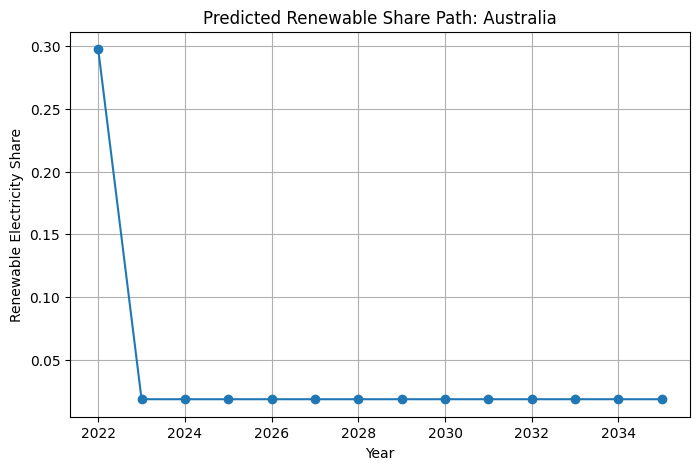

In [359]:
plt.figure(figsize=(8,5))

plt.plot(years, shares, marker="o")

plt.xlabel("Year")
plt.ylabel("Renewable Electricity Share")
plt.title(f"Predicted Renewable Share Path: {country_name39}")

plt.grid(True)

plt.show()

In [360]:
data3["year"].max()

np.int64(2021)

In [361]:
recent_data = future_data3[future_data3["year"] == future_data3["year"].max()].copy()
forecast_results = []

base_year = recent_data[["country", "year", "true_renew_share"]].copy()
base_year.rename(columns={"true_renew_share": "renew_share"}, inplace=True)
forecast_results.append(base_year)

current_data = recent_data.copy()

for year in range(2023, 2036):

    X_future = current_data[X3_columns]

    predictions = RF_model3.predict(X_future)

    new_share = current_data["true_renew_share"].values + predictions

    temp = current_data[["country"]].copy()
    temp["year"] = year
    temp["renew_share"] = new_share

    forecast_results.append(temp)

    current_data["renew_share_change"] = predictions
    current_data["true_renew_share"] = new_share
    current_data["year"] = year

forecast_df = pd.concat(forecast_results, ignore_index=True)

In [362]:
forecast_df.head(40)

,country,year,renew_share
0,Australia,2022,0.297586
1,Austria,2022,0.725035
2,Belgium,2022,0.217577
3,Brazil,2022,0.795535
4,Canada,2022,0.672674
5,China,2022,0.284272
6,Czechia,2022,0.074842
7,Denmark,2022,0.604727
8,Egypt,2022,0.125098
9,Estonia,2022,0.144056


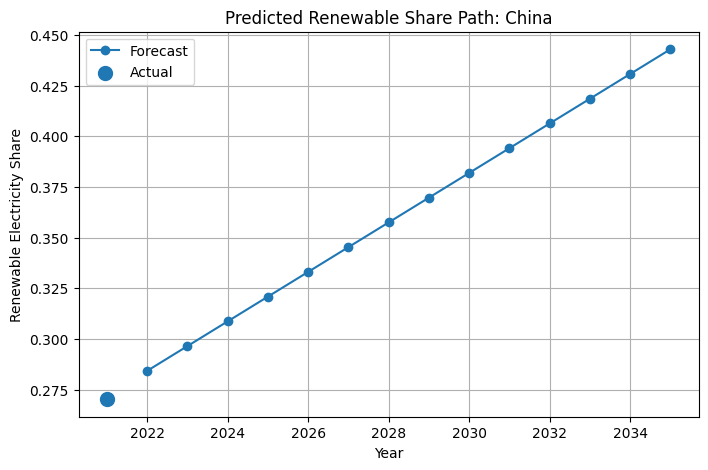

In [363]:
country_1 = "China"

country_path = forecast_df[forecast_df["country"] == country_1]

plt.figure(figsize=(8,5))

plt.plot(country_path["year"], country_path["renew_share"], marker="o", label="Forecast")

country_data = data3[data3["country"] == country_1]

latest_year = country_data["year"].max()

start_value = country_data[country_data["year"] == latest_year]["true_renew_share"].values[0]

plt.scatter(latest_year, start_value, s=100, label="Actual")

plt.xlabel("Year")
plt.ylabel("Renewable Electricity Share")
plt.title(f"Predicted Renewable Share Path: {country_1}")

plt.legend()
plt.grid(True)

plt.show()

In [364]:
# 1. Filter the forecast dataframe for your target country
target_country = "Australia"
country_table = forecast_df[forecast_df["country"] == target_country].copy()

# 2. Clean up the look: Sort by year and reset index for a clean 0, 1, 2...
country_table = country_table.sort_values("year").reset_index(drop=True)

# 3. Format the renewable share to look like a percentage (optional but helpful)
# This creates a new column where 0.269 becomes "26.98%"
country_table["renew_share_pct"] = (country_table["renew_share"] * 100).round(2).astype(str) + '%'

# 4. Display the table
print(f"\n--- Renewable Forecast Table: {target_country} ---")
print(country_table[["year", "renew_share", "renew_share_pct"]])


--- Renewable Forecast Table: Australia ---
    year  renew_share renew_share_pct
0   2022     0.297586          29.76%
1   2023     0.315907          31.59%
2   2024     0.334227          33.42%
3   2025     0.352547          35.25%
4   2026     0.370867          37.09%
5   2027     0.389188          38.92%
6   2028     0.407508          40.75%
7   2029     0.425828          42.58%
8   2030     0.444148          44.41%
9   2031     0.462469          46.25%
10  2032     0.480789          48.08%
11  2033     0.499109          49.91%
12  2034     0.517429          51.74%
13  2035     0.535750          53.57%


In [370]:
# 1. Select the historical columns we need (from your main dataset)
# We use data3 here because it contains all the years from 2000-2022
history = data3[data3["country"] == "United States"][["country", "year", "true_renew_share"]].copy()

# 2. Standardize column names so they match forecast_df
history.rename(columns={"true_renew_share": "renew_share"}, inplace=True)

# 3. Filter for specific starting years (e.g., from 2015 onwards)
history_from_2015 = history[history["year"] >= 2015]

# 4. Get the forecast for the same country (excluding 2022 if it's already in history)
forecast = forecast_df[(forecast_df["country"] == "United States") & (forecast_df["year"] > 2022)]

# 5. Combine them!
full_path = pd.concat([history_from_2015, forecast]).sort_values("year").reset_index(drop=True)

# 6. Add the change column
# .diff() looks at the 'renew_share' in the previous row and subtracts it from the current row
full_path["renew_share_change"] = full_path["renew_share"].diff()

# 7. Display the table
print(full_path)

          country  year  renew_share  renew_share_change
0   United States  2015     0.120098                 NaN
1   United States  2016     0.136626            0.016528
2   United States  2017     0.156790            0.020164
3   United States  2018     0.156392           -0.000398
4   United States  2019     0.164993            0.008601
5   United States  2020     0.185019            0.020026
6   United States  2021     0.189113            0.004094
7   United States  2023     0.219235            0.030122
8   United States  2024     0.232803            0.013568
9   United States  2025     0.246370            0.013568
10  United States  2026     0.259938            0.013568
11  United States  2027     0.273505            0.013568
12  United States  2028     0.287073            0.013568
13  United States  2029     0.300641            0.013568
14  United States  2030     0.314208            0.013568
15  United States  2031     0.327776            0.013568
16  United States  2032     0.3